# Separação para os dados de teste

## 1. Importação das bibliotecas

Para o treinamento adequado do modelo, é necessário usar a biblioteca sckit-learn para auxiliar no aprendizado de máquina, importando funções de métricas, seleção de dados para o treinamento e no modelo utilizado. Além disso, utilizou-se o pandas para manipulação do dataframe.

In [43]:
from sklearn.metrics import recall_score, f1_score, precision_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

## 2. Teste do modelo árvore de decisão

Uma árvore de decisão é um modelo visual e hierárquico, semelhante a um fluxograma, representando um processo de decisão, mostrando as etapas, escolhas e decisões.

### 2.1. Função geral para realizar as predições

Para facilitar a visualização das métricas do modelo, realizou-se a seguinte função para realizar isso:

In [44]:
def prediction_metrics(archive):
    # Leitura e preparação do dataframe
    df = pd.read_csv(archive)
    df["TempoQ3"] = df["TempoQ3"].fillna(df["TempoQ3"].mean())
    X = df.copy()
    if 'Oficinas' in X.columns:
        X = X.drop("Oficinas", axis = 1)
    if 'Aprovou_Aprovou' in X.columns:
        X = X.drop("Aprovou_Aprovou", axis = 1)
    if 'CalcNotaQuiz_scaled' in X.columns:
        X = X.drop("CalcNotaQuiz_scaled", axis = 1)

    # Preparação da label para realizar a predição
    y = df["Aprovou_Aprovou"]

    features_names = X.columns.tolist()

    # Separação dos dados em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify=y)

    # Configuração do GridSearch
    # Dicionário com os parâmetros de grid
    param_grid = {
        'criterion': ['gini', 'entropy'], # Medição da quantidade de um divisão ('gini' e 'entropy')
        'max_depth': [None, 5, 10, 15, 20], # Profundidade da árvore
        'min_samples_leaf': [1, 5, 10, 20] # O número mínimos de amostras que uma "folha" deve ter
    }

    # Criação de scorer para ser utilizado no grid search
    f1_score_reprovou = make_scorer(f1_score, pos_label=0)

    # Instanciação do gridSearch
    grid_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        scoring=f1_score_reprovou,
        cv=5, # Indica em quanta partes os dados de treino foram divididos para comparar os resultados 
        n_jobs=-1, # Define quantos núcleos serão direcionados para realizar a tarefa, -1 usar quantos estiverem disponíveis
        verbose=1 # Nível de detalhes que será exibido na execução do grid search
    )

    # Treinamento do modelo usando gridSearch
    print("\nIniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...")
    grid_search.fit(X_train, y_train)

    # Análise dos resultados obtidos
    print("\nMelhores parâmetros encontrados:")
    print(grid_search.best_params_)

    # Escolher o melhor modelo
    best_model = grid_search.best_estimator_
    print("\nFeatures mais importantes:")

    print("\nCalculando a importância de cada feature para o modelo...")

    # Pega as importâncias calculadas pelo melhor modelo
    importances = best_model.feature_importances_

    # Cria um DataFrame do Pandas para facilitar a visualização
    feature_importance_df = pd.DataFrame({
        'Feature': features_names,
        'Importance': importances
    })

    # Ordena o DataFrame para ver as features mais importantes no topo
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Importância das features
    print("\nImportância de cada feature (de 0 a 1):")
    print(feature_importance_df)

    # Plotando o gráfico de importância
    print("\nGerando o gráfico de importância das features...")

    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel("Importância (Normalizada)")
    plt.ylabel("Feature")
    plt.title("Importância das Features no Modelo de Decisão")
    plt.gca().invert_yaxis() # Inverte o eixo para a mais importante ficar no topo
    plt.show()

    # Plotar a árvore
    print("\nPlotando a árvore de decisão...")
    plt.figure(figsize=(25, 15))

    plot_tree(
        best_model,
        feature_names=features_names,
        class_names=['Reprovou', 'Aprovou'],
        filled=True,
        rounded=True,
        fontsize=10
    )

    plt.title("Melhor árvore de decisão encontrada pelo GridSearchCV")
    plt.show()

    # Realizar a predição
    y_pred = best_model.predict(X_test)

    # Definição e execução do modelo sem o gridSearch
    # model = DecisionTreeClassifier()
    # model.fit(X_train, y_train)
    # y_pred = model.predict(X_test)

    # Métricas obtidas:
    print("\n--- Métricas obtidas ---")
    recall = recall_score(y_test, y_pred, pos_label=0)
    print(f"Recall: {recall}")

    precision = precision_score(y_test, y_pred, pos_label=0)
    print(f"Precisão: {precision}")

    f1score = f1_score(y_test, y_pred, pos_label=0)
    print(f"F1 Score: {f1score}")


### 2.1.1. Teste com o dataframe completo

Primeiro teste do modelo de árvore de decisão com o dataframe completo


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits



Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}

Features mais importantes:

Calculando a importância de cada feature para o modelo...

Importância de cada feature (de 0 a 1):
                    Feature  Importance
14           Projeto_Parte1    0.503963
17                Parcial_2    0.184064
16                Parcial_1    0.129338
13                  TempoQ7    0.074942
12                  TempoQ6    0.036078
1                     Quiz2    0.032793
11                  TempoQ5    0.021337
15           Projeto_Parte2    0.013511
7                   TempoQ1    0.003974
5                     Quiz6    0.000000
0                     Quiz1    0.000000
4                     Quiz5    0.000000
3                     Quiz4    0.000000
2                     Quiz3    0.000000
10                  TempoQ4    0.000000
6                     Quiz7    0.000000
8                   TempoQ2    0.000000
9                   TempoQ3    0.000000
18        

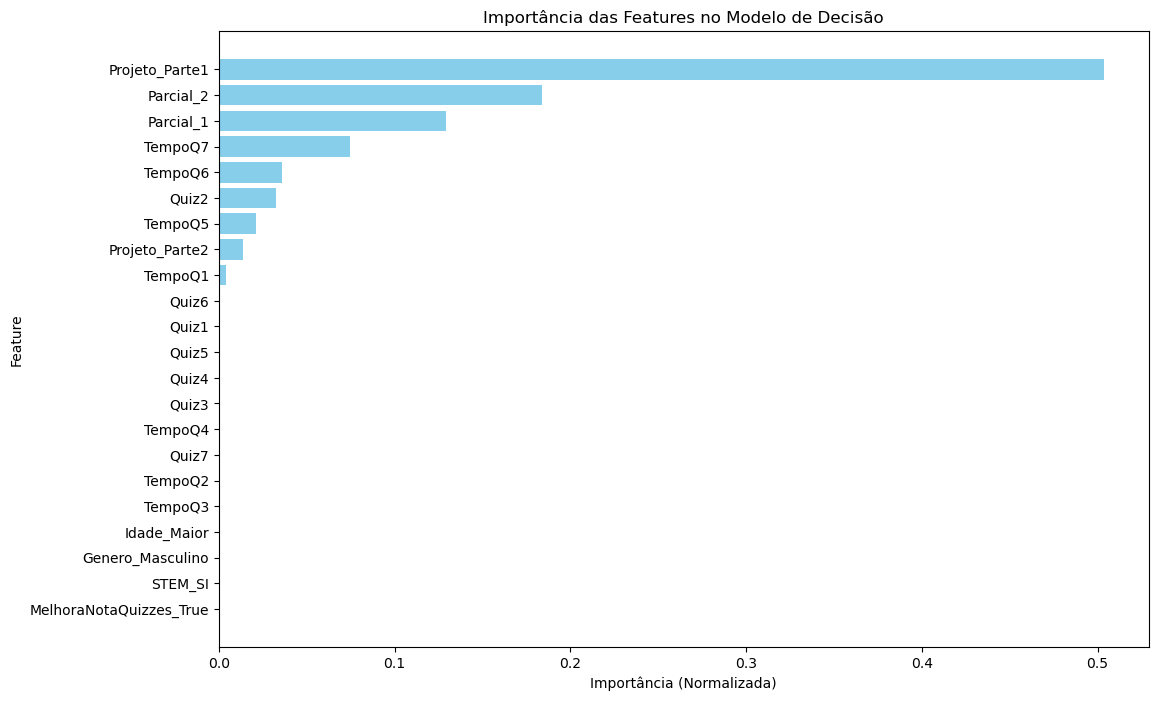


Plotando a árvore de decisão...


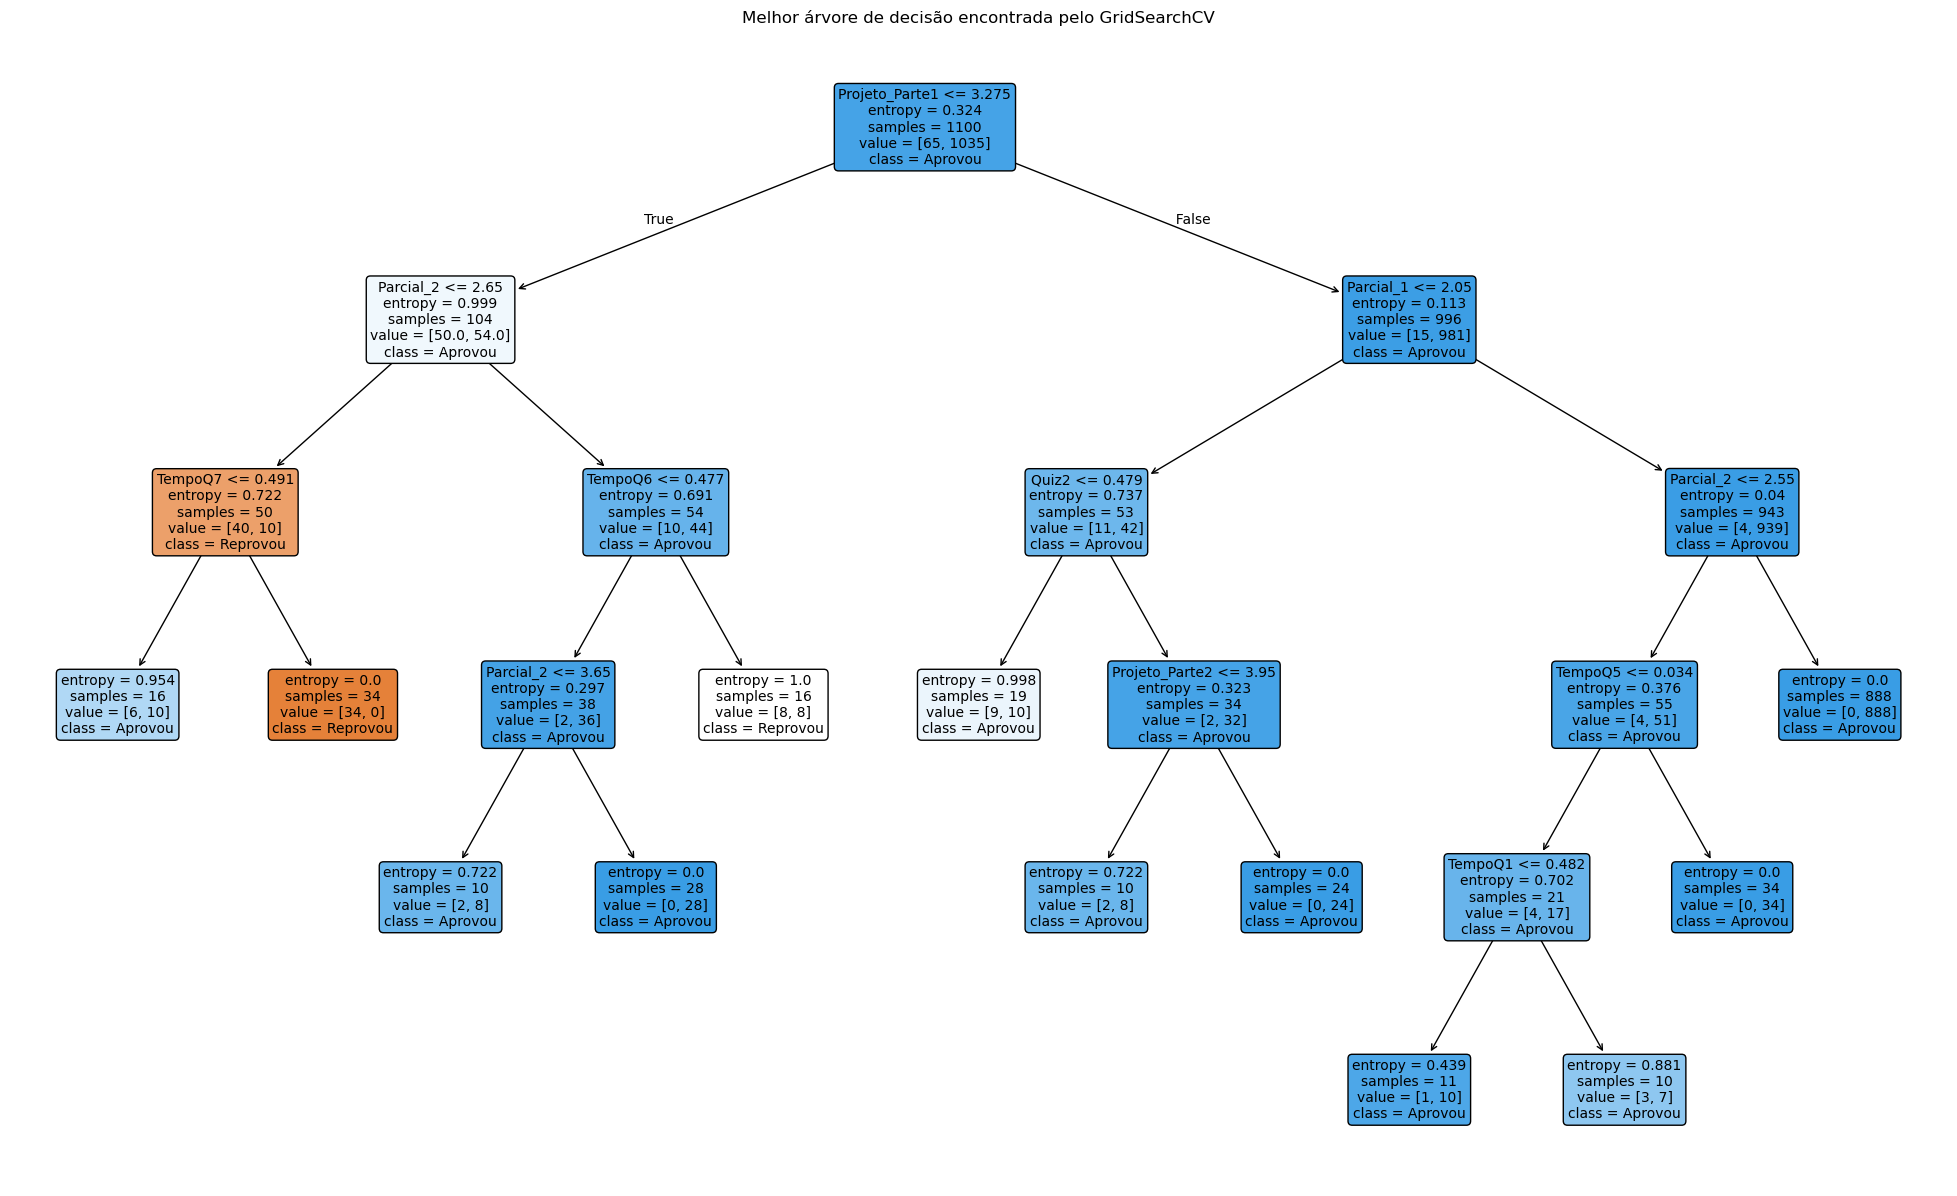


--- Métricas obtidas ---
Recall: 0.6875
Precisão: 0.5789473684210527
F1 Score: 0.6285714285714286


In [45]:
# Para evitar uma mensagem de erro desnecessária, ocasionado pelo ResourceTracker, utiliza-se o seguinte condicional que será repetido nos próximos datasets
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo.csv")

### 2.1.2. Teste com o dataframe da semana 4

Segundo teste com os dados referentes à primeira predição do curso


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1}

Features mais importantes:

Calculando a importância de cada feature para o modelo...

Importância de cada feature (de 0 a 1):
       Feature  Importance
5      TempoQ1    0.282350
7      TempoQ3    0.231748
3        Quiz2    0.138846
6      TempoQ2    0.109157
4        Quiz3    0.105605
2        Quiz1    0.082515
0  Idade_Maior    0.032520
1      STEM_SI    0.017259

Gerando o gráfico de importância das features...


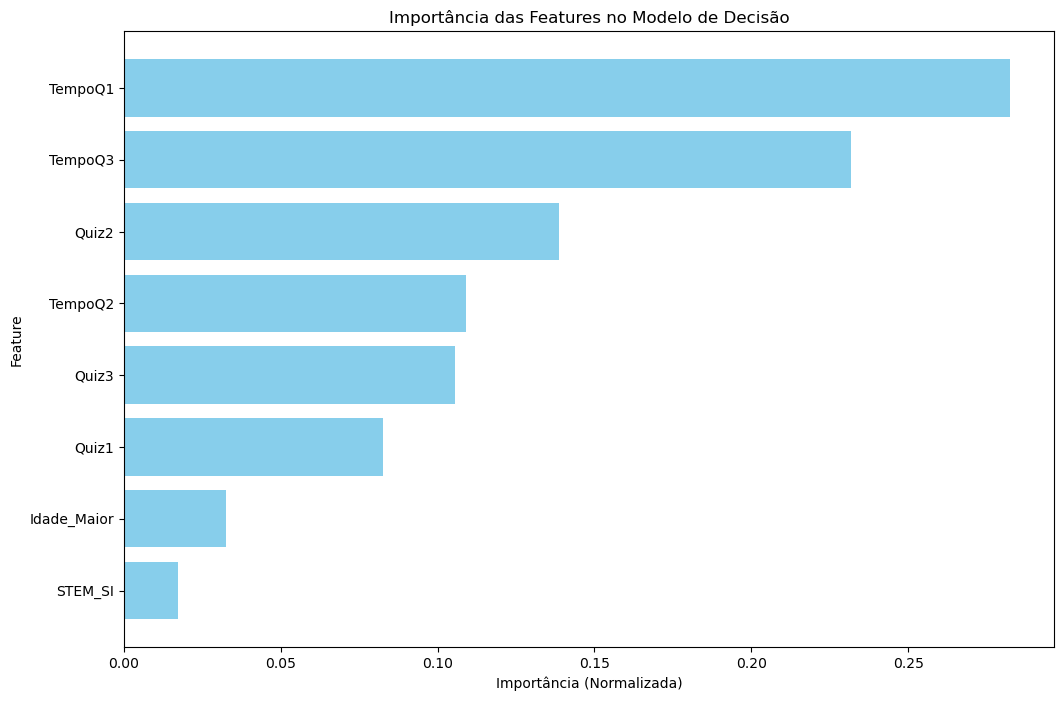


Plotando a árvore de decisão...


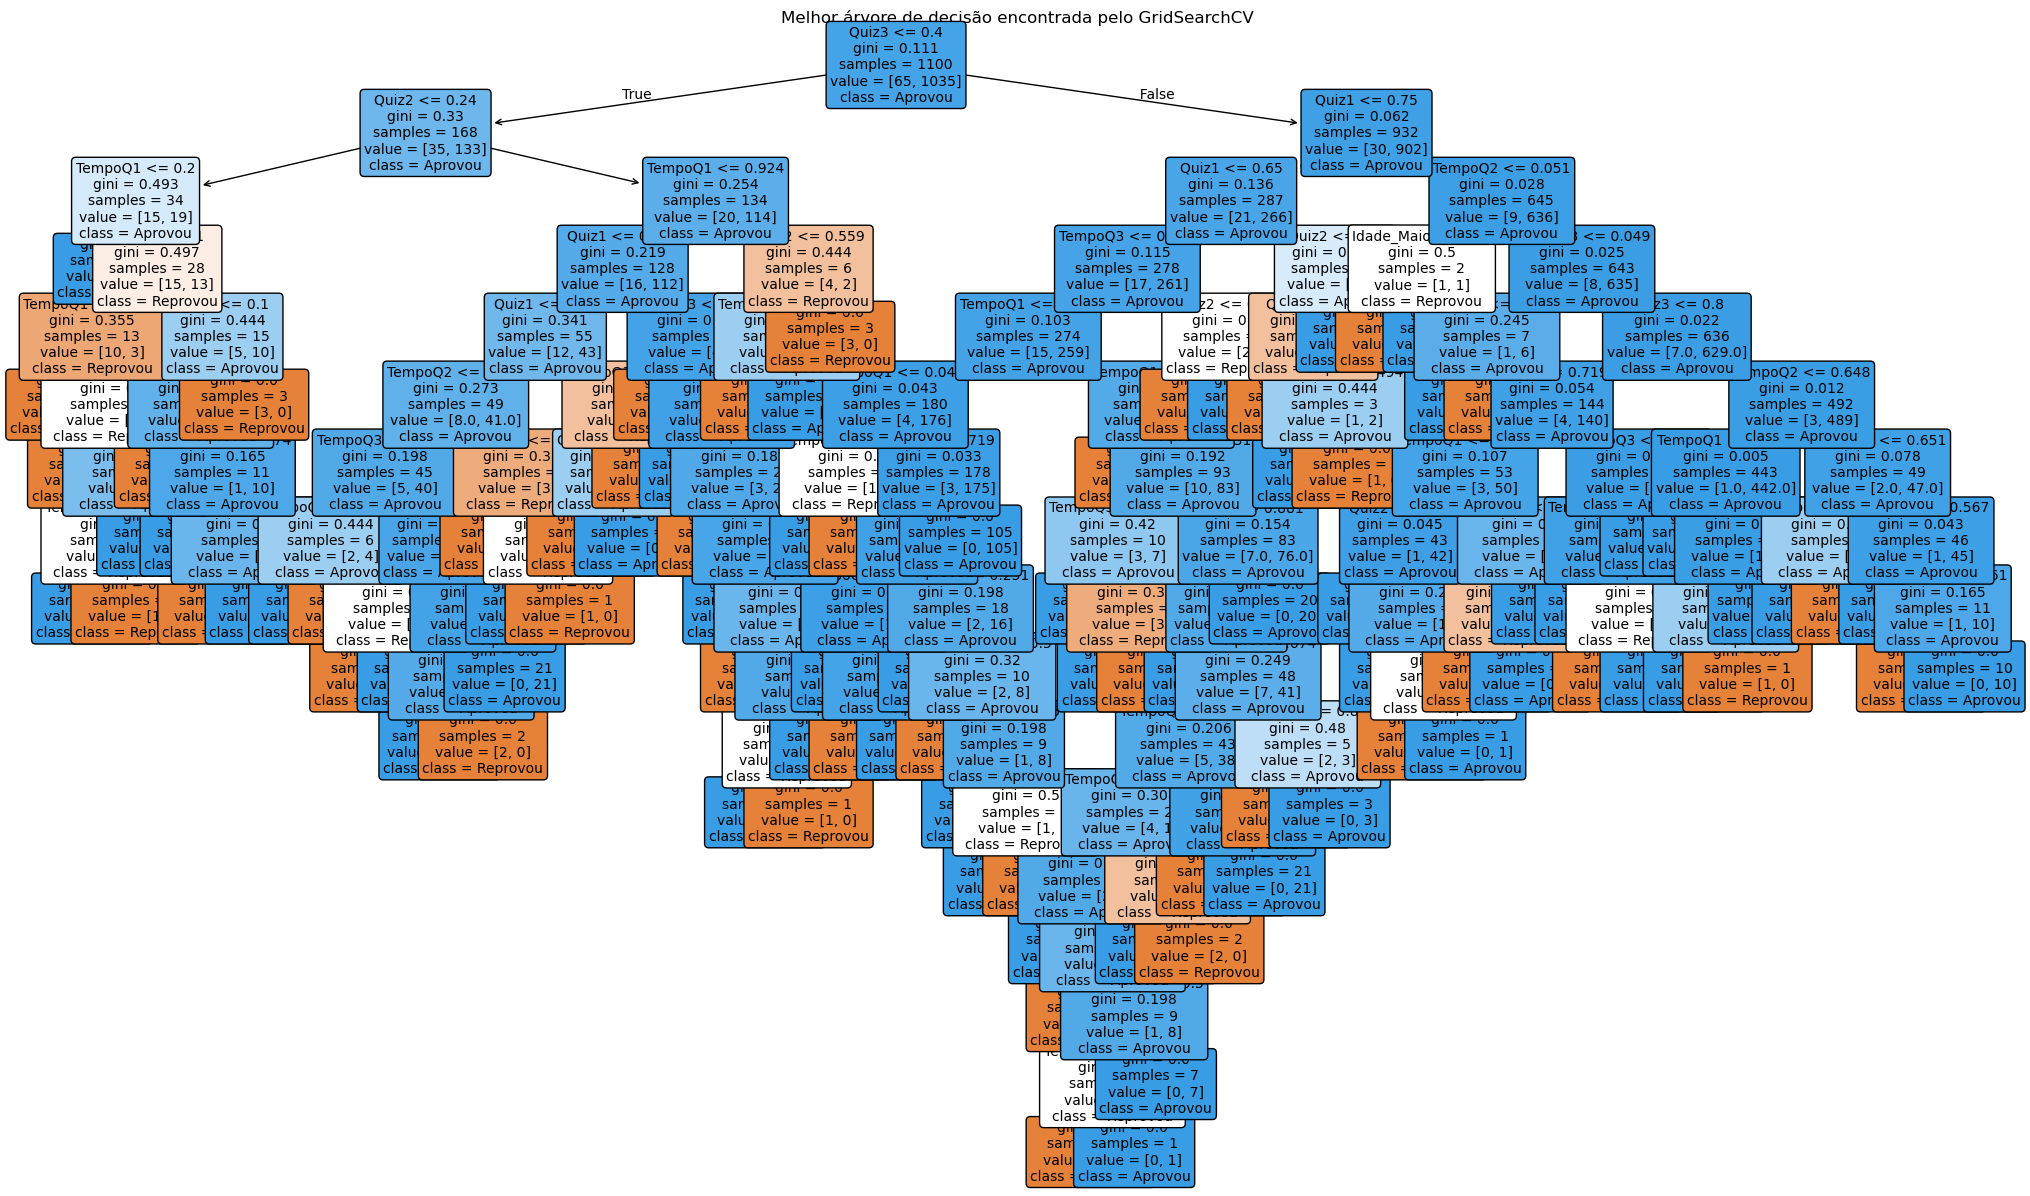


--- Métricas obtidas ---
Recall: 0.25
Precisão: 0.19047619047619047
F1 Score: 0.21621621621621623


In [46]:
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo1.csv")

### 2.1.3 Teste com o dataframe da semana 8

Terceiro teste com os dados referentes à segunda predição do curso


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1}

Features mais importantes:

Calculando a importância de cada feature para o modelo...

Importância de cada feature (de 0 a 1):
        Feature  Importance
10    Parcial_1    0.484971
9       TempoQ4    0.166150
5         Quiz4    0.085491
4         Quiz3    0.079298
8       TempoQ3    0.057598
6       TempoQ1    0.040090
7       TempoQ2    0.031100
3         Quiz2    0.030934
2         Quiz1    0.024370
1       STEM_SI    0.000000
0   Idade_Maior    0.000000

Gerando o gráfico de importância das features...


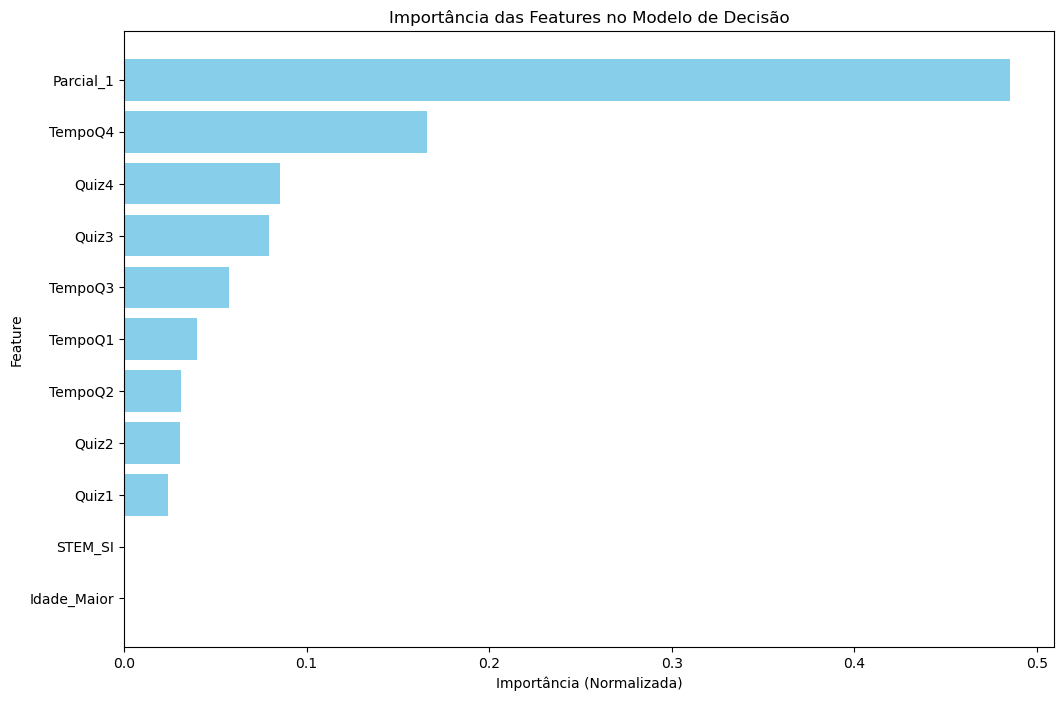


Plotando a árvore de decisão...


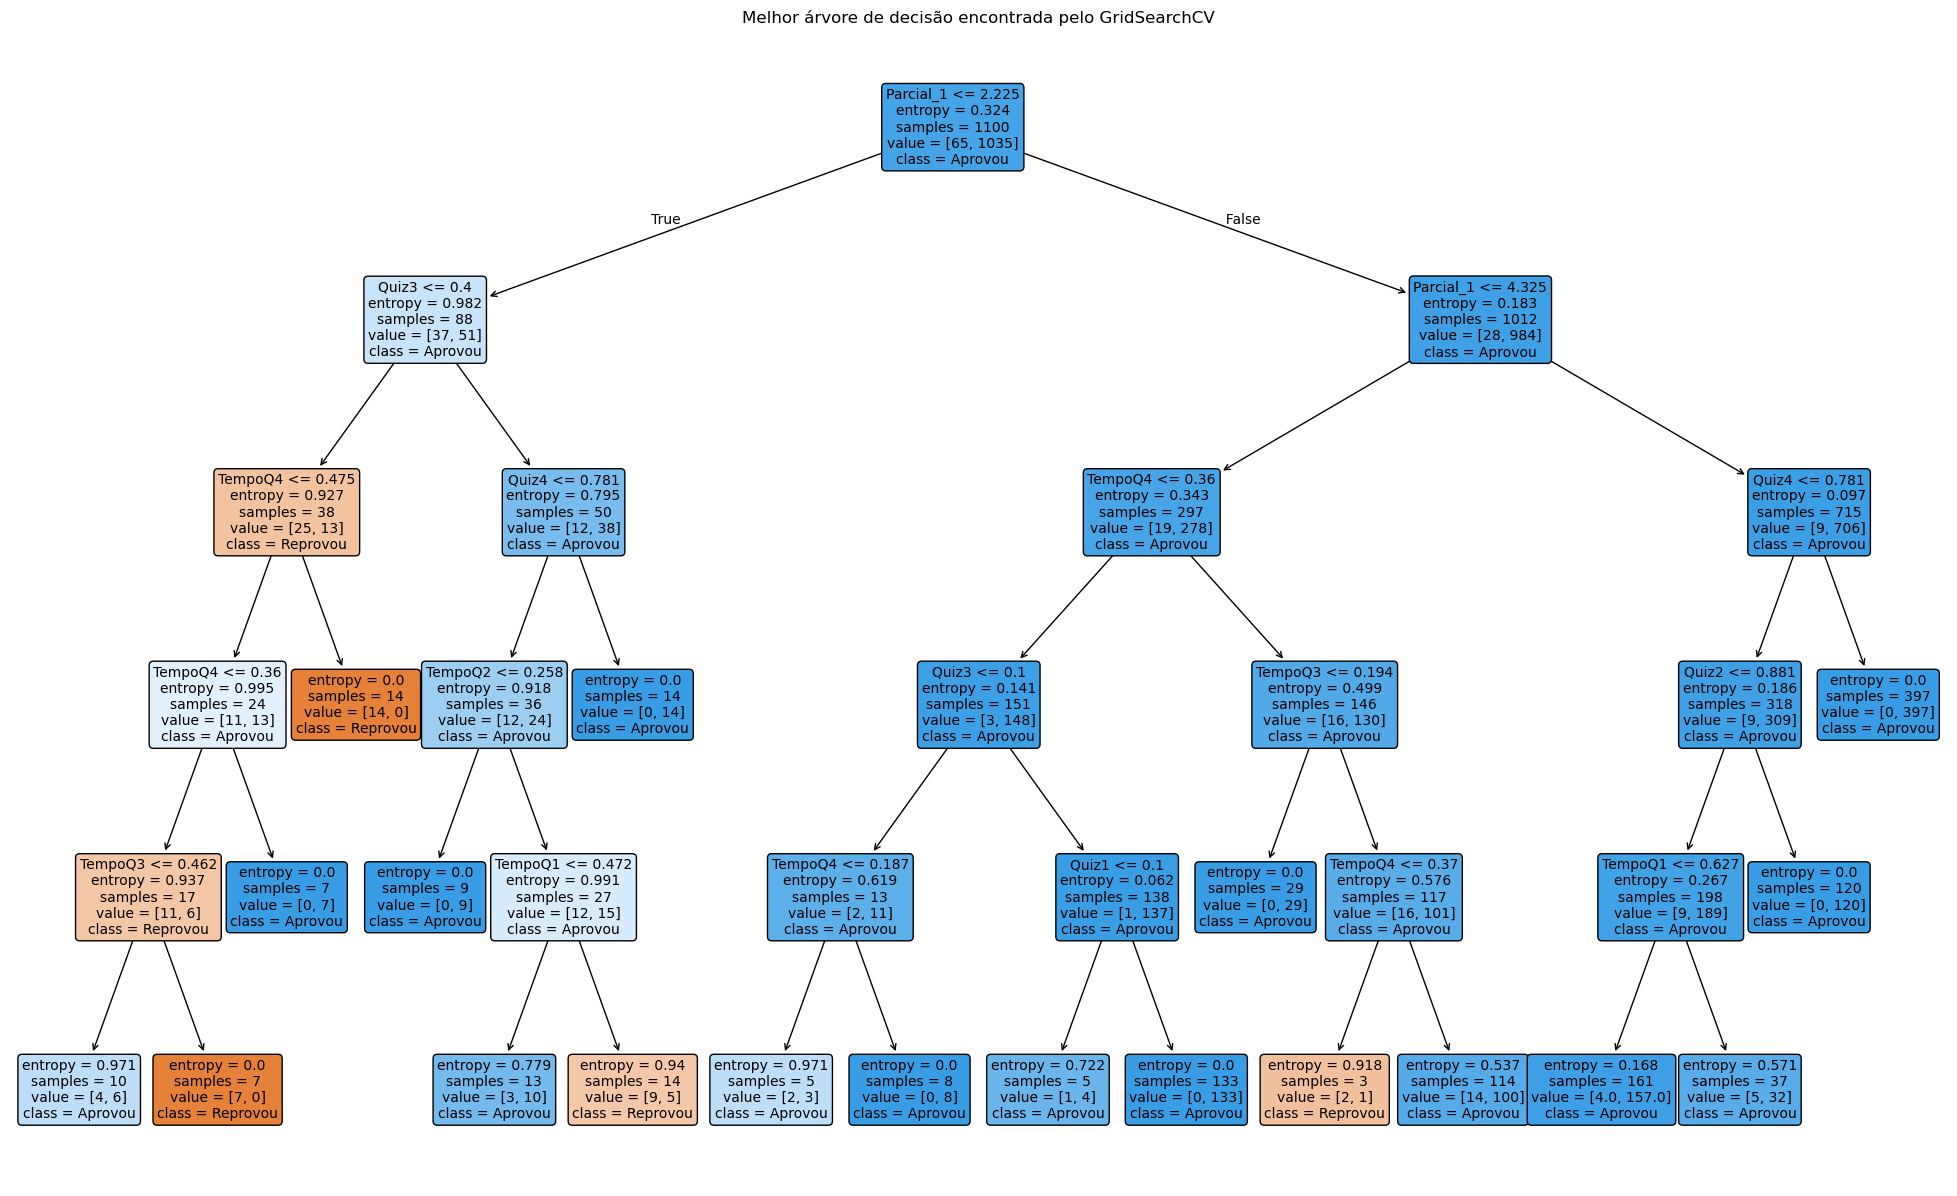


--- Métricas obtidas ---
Recall: 0.3125
Precisão: 0.38461538461538464
F1 Score: 0.3448275862068966


In [47]:
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo2.csv")

### 2.1.4 Teste com o dataframe da semana 12

Quarto teste com os dados referentes à terceira predição do curso


Iniciando o treinamento do modelo usando o grid search na busca dos melhores parâmetros...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5}

Features mais importantes:

Calculando a importância de cada feature para o modelo...

Importância de cada feature (de 0 a 1):
        Feature  Importance
14    Parcial_1    0.387853
13      TempoQ6    0.211884
6         Quiz5    0.097562
11      TempoQ4    0.078166
10      TempoQ3    0.058593
5         Quiz4    0.040189
12      TempoQ5    0.038152
4         Quiz3    0.035716
2         Quiz1    0.022762
3         Quiz2    0.019973
9       TempoQ2    0.009150
0   Idade_Maior    0.000000
1       STEM_SI    0.000000
7         Quiz6    0.000000
8       TempoQ1    0.000000

Gerando o gráfico de importância das features...


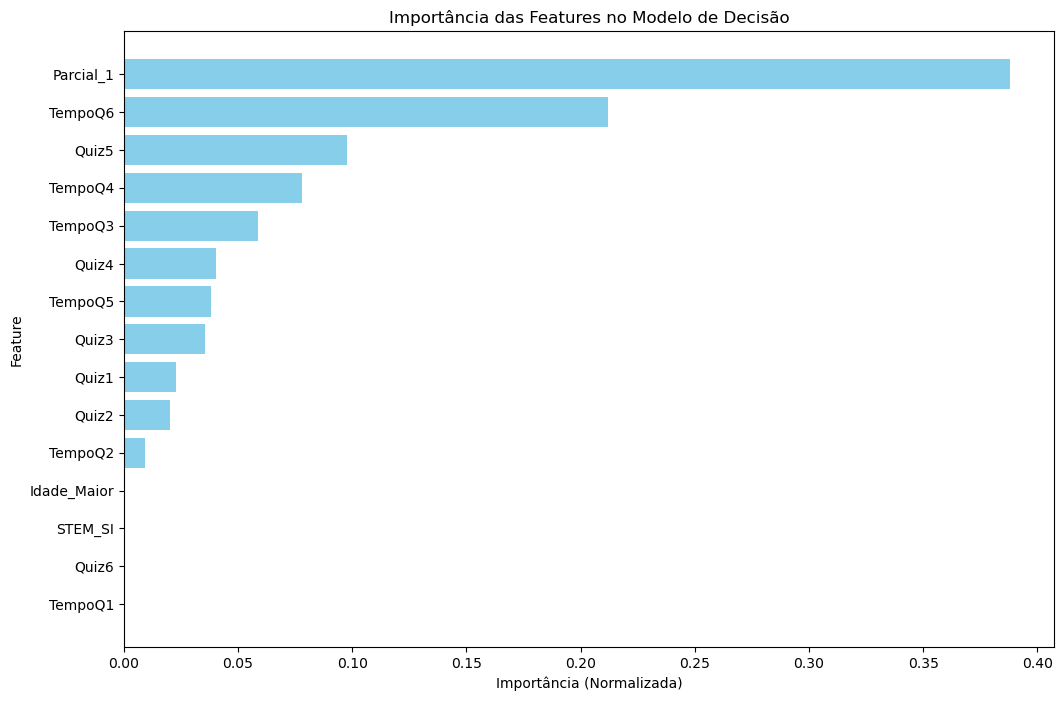


Plotando a árvore de decisão...


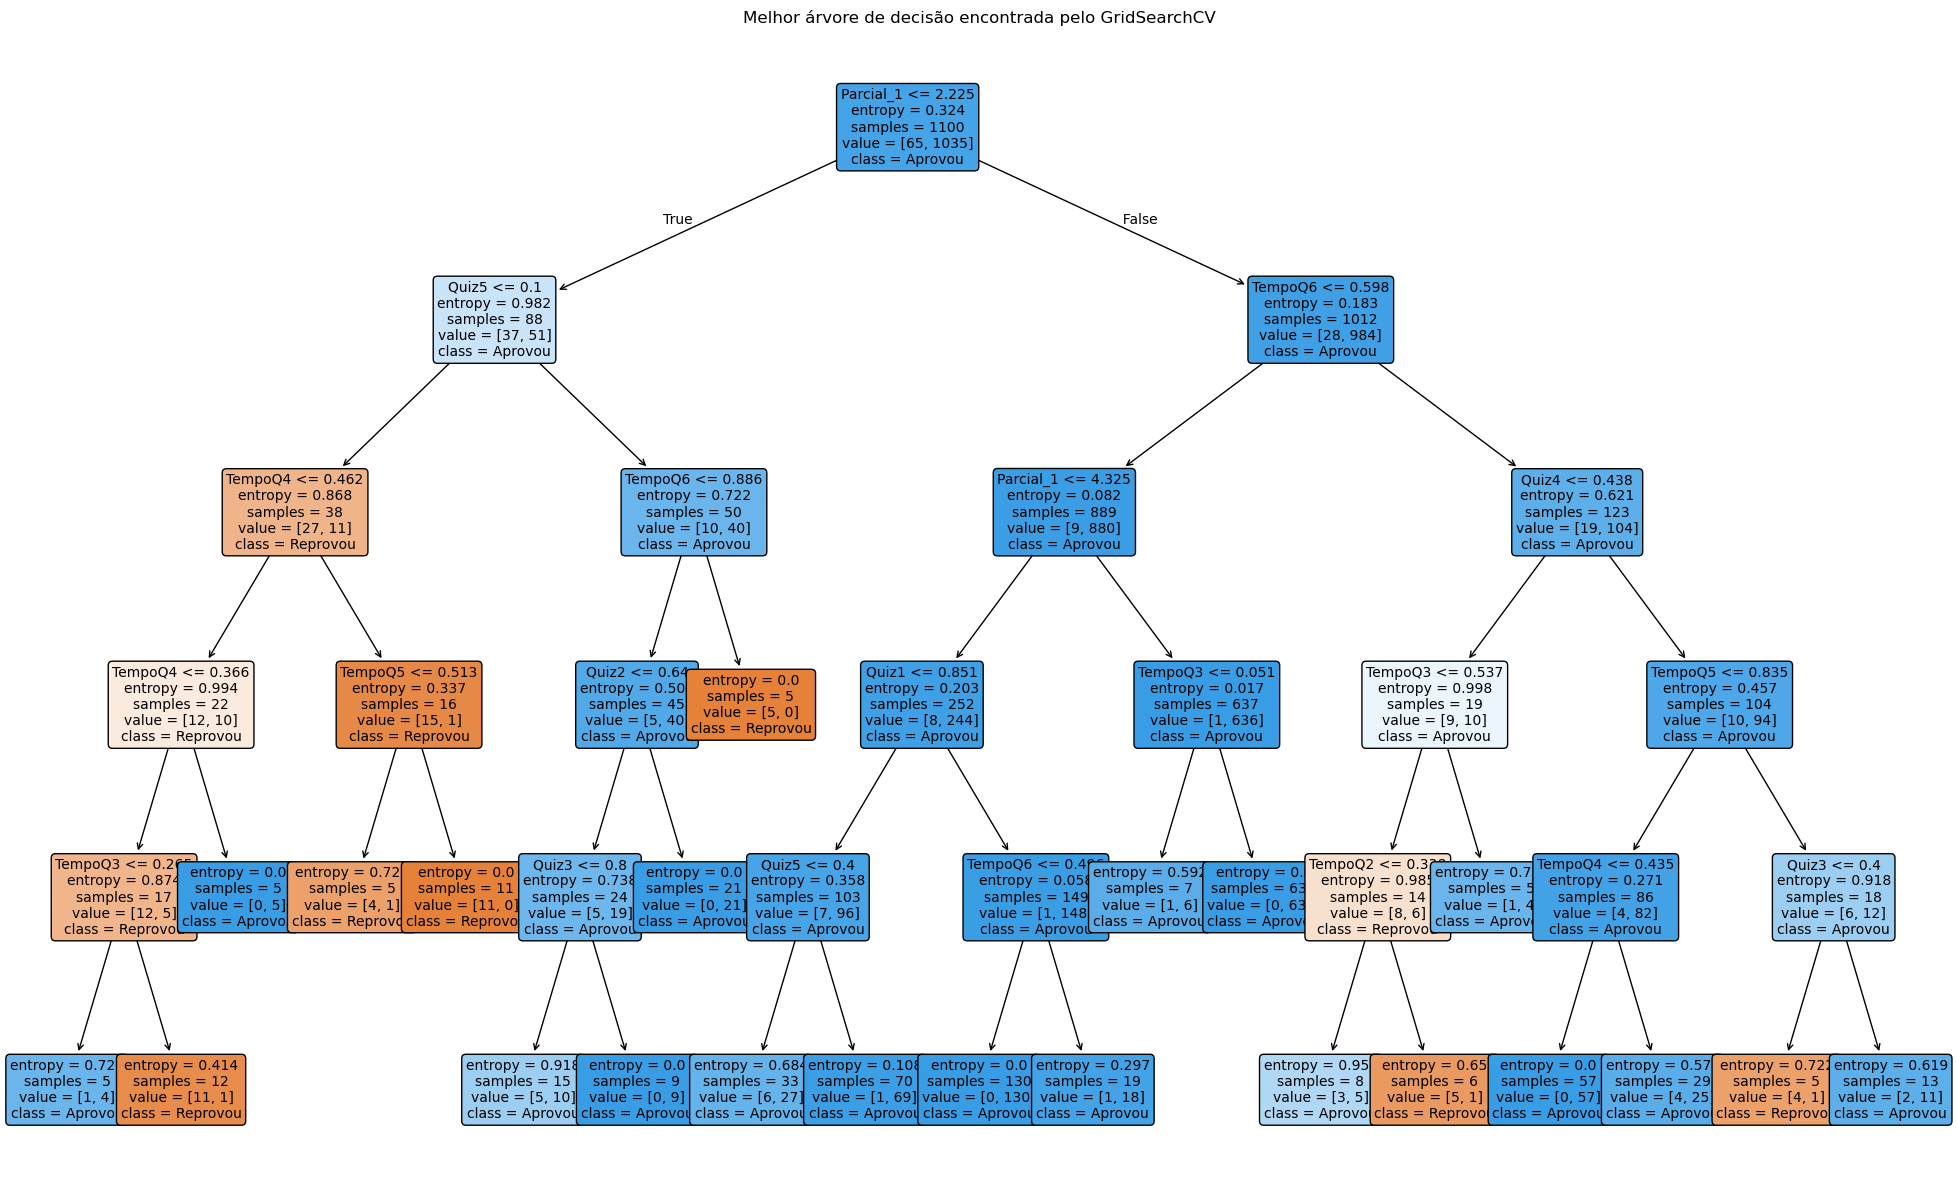


--- Métricas obtidas ---
Recall: 0.375
Precisão: 0.4
F1 Score: 0.3870967741935484


Exception ignored in: <function ResourceTracker.__del__ at 0x76bbc15847c0>
Traceback (most recent call last):
  File "/home/messiasolivindo/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/messiasolivindo/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/messiasolivindo/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7dc35b7907c0>
Traceback (most recent call last):
  File "/home/messiasolivindo/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/messiasolivindo/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/messiasolivindo/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child proces

In [ ]:
if __name__ == '__main__':
    prediction_metrics("dados/dados_modelo3.csv")

## 3. Conclusões

Observa-se que as métricas obtidas com o modelo são muito baixas, sendo um modelo muito ineficiente com a nota da primeira prova como dado de maior impacto nesse modelo.